In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime

mpl.rcParams['figure.figsize'] = (10,8)
mpl.rcParams['axes.grid'] = False

In [2]:
def parse(x):
    return datetime.strptime(x, '%m/%d/%Y')

In [3]:
df = pd.read_csv('/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/ML Micro Projects/data/raw/amazon_revenue_profit.csv', parse_dates= ['Quarter'], date_parser=parse)

/var/folders/4b/f46tx7f94tddgdzqfc22ctw80000gn/T/ipykernel_20267/1270354297.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv('/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/ML Micro Projects/data/raw/amazon_revenue_profit.csv', parse_dates= ['Quarter'], date_parser=parse)


In [4]:
df

,Quarter,Revenue,Net Income
0,2020-03-31,75452,2535
1,2019-12-31,87437,3268
2,2019-09-30,69981,2134
3,2019-06-30,63404,2625
4,2019-03-31,59700,3561
...,...,...,...
56,2006-03-31,2279,51
57,2005-12-31,2977,199
58,2005-09-30,1858,30
59,2005-06-30,1753,52


In [14]:
amazon_df = df.set_index('Quarter')

In [5]:
import plotly.express as px

In [8]:
fig = px.line(df, x='Quarter', y='Revenue', title='Amazon Revenue Over Time')

fig.update_xaxes(
    rangeslider_visible = True,
    rangeselector = dict(
        buttons = list([
            dict(count=1, label="1y", step = "year", stepmode="backward"),
            dict(count=2, label="2y", step = "year", stepmode="backward"),
            dict(count=3, label="3y", step = "year", stepmode="backward"),
            dict(step = "all")
        ])
    ))
fig.show()

KPSS TEST

Null hypothesis - data is stationary............
 Alternate hypothesis - data is not stationary

In [9]:
from statsmodels.tsa.stattools import kpss

**KPSS Test Statistic Formula**

The KPSS (Kwiatkowski-Phillips-Schmidt-Shin) test statistic is calculated as:

$$
\text{KPSS} = \frac{1}{T^2} \sum_{t=1}^{T} S_t^2 \Big/ \hat{\sigma}^2
$$

where:

- $T$ = number of observations
- $S_t = \sum_{i=1}^{t} e_i$ is the cumulative sum of residuals up to time $t$
- $e_i$ = residuals from the regression of the time series on the deterministic component (constant or trend)
- $\hat{\sigma}^2$ = estimator of the long-run variance of $e_i$

The test checks for stationarity around a deterministic trend (or level).


In [10]:
tstest = kpss(df['Revenue'], 'ct')

/var/folders/4b/f46tx7f94tddgdzqfc22ctw80000gn/T/ipykernel_20267/3465168009.py:1: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




In [11]:
tstest

(np.float64(0.3066554597516947),
 np.float64(0.01),
 4,
 {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216})

<br><br>
<br><br>
**Additive time series model formula:**  
$Y_t = T_t + S_t + C_t + E_t$  
where  
$Y_t$ = observed value at time $t$  
$T_t$ = trend component  
$S_t$ = seasonal component  
$C_t$ = cyclic component  
$E_t$ = error (residual) component  
<br><br>
**Multiplicative time series model formula:**  
$Y_t = T_t \times S_t \times C_t \times E_t$  
where  
$Y_t$ = observed value at time $t$  
$T_t$ = trend component  
$S_t$ = seasonal component  
$C_t$ = cyclic component  
$E_t$ = error (residual) component

In [19]:
amazon_df = amazon_df[::-1]

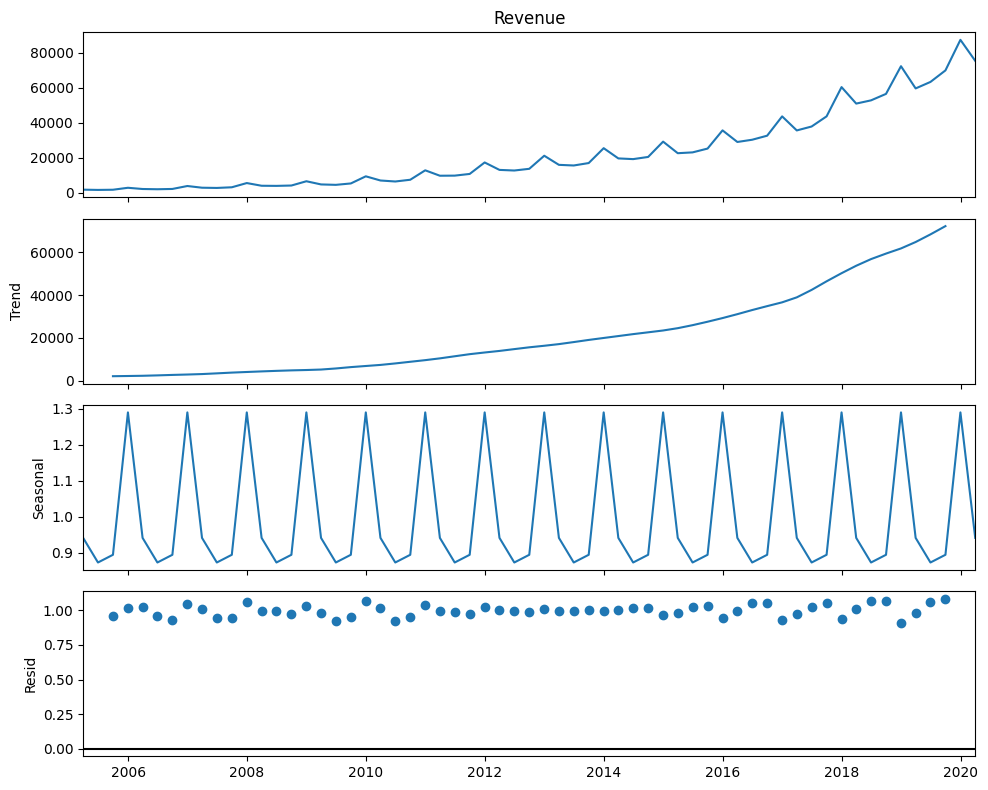

In [20]:
import statsmodels.api as sm

res = sm.tsa.seasonal_decompose(amazon_df['Revenue'], model='multiplicative')

resplot = res.plot()


<Axes: xlabel='Quarter'>

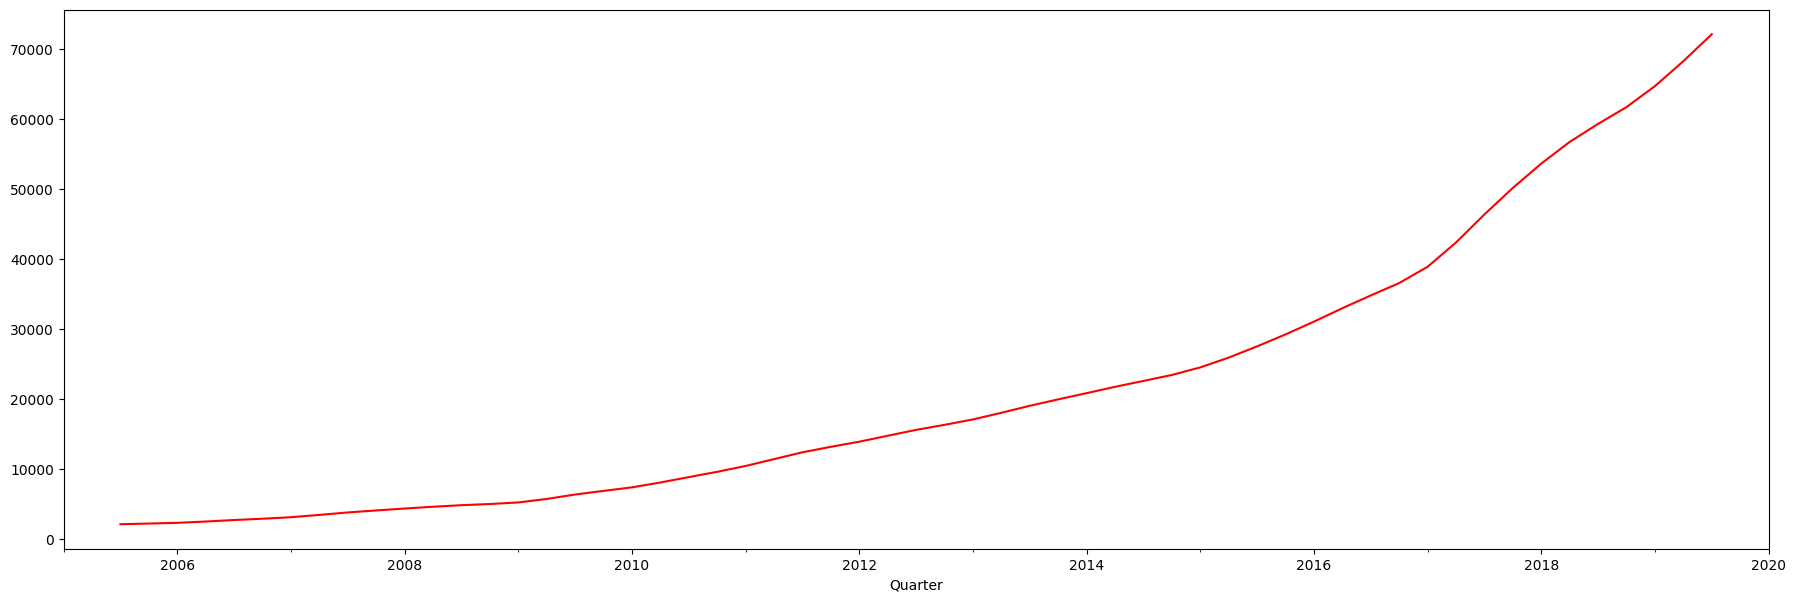

In [21]:
plt.figure(figsize=(22,7))
res.trend.plot(label='Trend', color='red')

In [22]:
res.observed

Quarter
2005-03-31     1902.0
2005-06-30     1753.0
2005-09-30     1858.0
2005-12-31     2977.0
2006-03-31     2279.0
               ...   
2019-03-31    59700.0
2019-06-30    63404.0
2019-09-30    69981.0
2019-12-31    87437.0
2020-03-31    75452.0
Name: Revenue, Length: 61, dtype: float64

In [23]:
print(res.trend)

Quarter
2005-03-31          NaN
2005-06-30          NaN
2005-09-30     2169.625
2005-12-31     2265.000
2006-03-31     2369.375
                ...    
2019-03-31    64691.375
2019-06-30    68248.750
2019-09-30    72099.500
2019-12-31          NaN
2020-03-31          NaN
Name: trend, Length: 61, dtype: float64


In [24]:
print(res.seasonal)

Quarter
2005-03-31    0.941840
2005-06-30    0.873649
2005-09-30    0.894993
2005-12-31    1.289518
2006-03-31    0.941840
                ...   
2019-03-31    0.941840
2019-06-30    0.873649
2019-09-30    0.894993
2019-12-31    1.289518
2020-03-31    0.941840
Name: seasonal, Length: 61, dtype: float64


In [25]:
res.resid

Quarter
2005-03-31         NaN
2005-06-30         NaN
2005-09-30    0.956844
2005-12-31    1.019256
2006-03-31    1.021253
                ...   
2019-03-31    0.979831
2019-06-30    1.063372
2019-09-30    1.084496
2019-12-31         NaN
2020-03-31         NaN
Name: resid, Length: 61, dtype: float64

In [26]:
res.observed[2]

/var/folders/4b/f46tx7f94tddgdzqfc22ctw80000gn/T/ipykernel_20267/1970690673.py:1: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



np.float64(1858.0)

In [27]:
res.trend[2]*res.seasonal[2]*res.resid[2]

/var/folders/4b/f46tx7f94tddgdzqfc22ctw80000gn/T/ipykernel_20267/1852622839.py:1: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



np.float64(1857.9999999999998)

<Axes: xlabel='Quarter'>

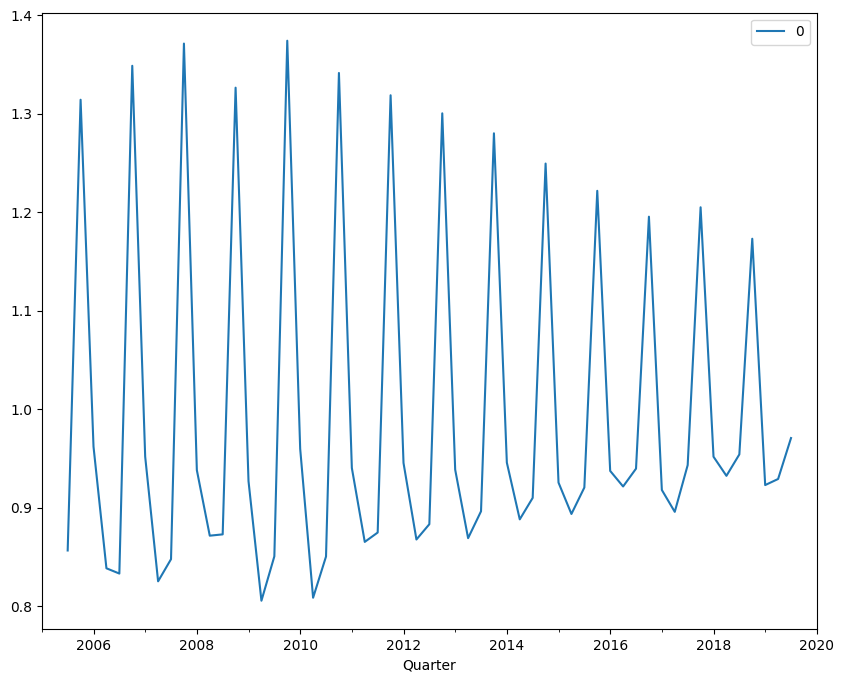

In [28]:
pd.DataFrame(res.observed/res.trend).plot()